In [39]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import timedelta

In [42]:
df = pd.read_parquet('/home/camarada/Documents/projects/temp-grss-nasa/data_/wunderground/Revision_temp_time.parquet')
df['time_max'] = pd.to_datetime(df['time_of_max_temp'], format= "%I:%M %p",errors='coerce').dt.time  
df['time_min'] = pd.to_datetime(df['time_of_min_temp'], format= "%I:%M %p",errors='coerce').dt.time 

## get date 
df['date_str'] = df['source_file'].apply(lambda x:x.strip().split('_',1)[1].replace('_','-'))
df['date']= pd.to_datetime(df['date_str'], format='%Y-%m-%d')
df['datetime_max']= pd.to_datetime(df['date_str'] + ' ' + df['time_of_max_temp'], format='%Y-%m-%d %I:%M %p')
df['datetime_min']= pd.to_datetime(df['date_str'] + ' ' + df['time_of_min_temp'], format='%Y-%m-%d %I:%M %p')

## diference between max min temperature 
df['diff_temp'] = df['max_temp'] - df['min_temp']

# difference of time between the min and the max 
## pass to time delta to calculate the diff
df['diff_time'] = df['time_max'].apply(lambda x: timedelta(hours=x.hour, minutes=x.minute)) - df['time_min'].apply(lambda x: timedelta(hours=x.hour, minutes=x.minute))

## add season column
df['season'] = df['date'].dt.month%12 // 3 + 1
df['season'] = df['season'].map({1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'})

In [43]:
df

,source_file,max_temp,min_temp,time_of_max_temp,time_of_min_temp,time_max,time_min,date_str,date,datetime_max,datetime_min,diff_temp,diff_time,season
0,EGLC_2020_01_01,45.0,36.0,3:20 PM,5:50 AM,15:20:00,05:50:00,2020-01-01,2020-01-01,2020-01-01 15:20:00,2020-01-01 05:50:00,9.0,0 days 09:30:00,Winter
1,EGLC_2020_01_02,52.0,45.0,12:50 PM,12:20 AM,12:50:00,00:20:00,2020-01-02,2020-01-02,2020-01-02 12:50:00,2020-01-02 00:20:00,7.0,0 days 12:30:00,Winter
2,EGLC_2020_01_03,54.0,45.0,3:50 AM,5:50 PM,03:50:00,17:50:00,2020-01-03,2020-01-03,2020-01-03 03:50:00,2020-01-03 17:50:00,9.0,-1 days +10:00:00,Winter
3,EGLC_2020_01_04,48.0,41.0,12:20 PM,12:50 AM,12:20:00,00:50:00,2020-01-04,2020-01-04,2020-01-04 12:20:00,2020-01-04 00:50:00,7.0,0 days 11:30:00,Winter
4,EGLC_2020_01_05,48.0,45.0,10:50 AM,6:20 AM,10:50:00,06:20:00,2020-01-05,2020-01-05,2020-01-05 10:50:00,2020-01-05 06:20:00,3.0,0 days 04:30:00,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2197,EGLC_2026_02_15,48.0,37.0,5:50 PM,6:20 AM,17:50:00,06:20:00,2026-02-15,2026-02-15,2026-02-15 17:50:00,2026-02-15 06:20:00,11.0,0 days 11:30:00,Winter
2198,EGLC_2026_02_16,50.0,43.0,1:20 PM,1:50 AM,13:20:00,01:50:00,2026-02-16,2026-02-16,2026-02-16 13:20:00,2026-02-16 01:50:00,7.0,0 days 11:30:00,Winter
2199,EGLC_2026_02_17,45.0,37.0,12:20 AM,6:20 AM,00:20:00,06:20:00,2026-02-17,2026-02-17,2026-02-17 00:20:00,2026-02-17 06:20:00,8.0,-1 days +18:00:00,Winter
2200,EGLC_2026_02_18,43.0,36.0,11:20 AM,12:50 AM,11:20:00,00:50:00,2026-02-18,2026-02-18,2026-02-18 11:20:00,2026-02-18 00:50:00,7.0,0 days 10:30:00,Winter


In [46]:
df['time_max'].plot(kind='hist')

TypeError: no numeric data to plot

<Axes: ylabel='Frequency'>

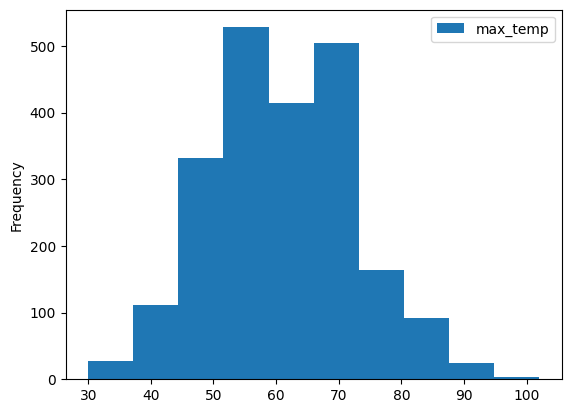

In [37]:
df.set_index('time_max')[['max_temp']].plot(kind='hist')


In [27]:
fig = px.histogram(df.set_index(['time_max']), x='max_temp',
                   labels = df['time_max'], nbins=24, title='Distribution of Time of Max Temperature')
fig.update_layout(xaxis_title='Time of Max Temperature', yaxis_title='Count')


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'bingroup': 'x',
              'hovertemplate': 'max_temp=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': '',
              'nbinsx': 24,
              'orientation': 'v',
              'showlegend': False,
              'type': 'histogram',
              'x': {'bdata': ('AAAAAACARkAAAAAAAABKQAAAAAAAAE' ... 'AAAACARkAAAAAAAIBFQAAAAAAAgEZA'),
                    'dtype': 'f8'},
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'barmode': 'relative',
               'legend': {'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Distribution of Time of Max Temperature'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Time of Max Temperature'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'Count'}}}
})

In [14]:
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed